In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


X_train = pd.read_csv('processed/splits/X_train_all.csv') 
X_val = pd.read_csv('processed/splits/X_val_all.csv')
X_test = pd.read_csv('processed/splits/X_test_all.csv')

y_train = pd.read_csv('processed/splits/y_train_all.csv').squeeze()
y_val = pd.read_csv('processed/splits/y_val_all.csv').squeeze()
y_test = pd.read_csv('processed/splits/y_test_all.csv').squeeze()
print(f"Форма данных: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")


Форма данных: Train=(3180741, 55), Val=(681587, 55), Test=(681588, 55)


In [8]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    roc_curve, auc, roc_auc_score, f1_score, precision_score, recall_score
)
# 1. Вычисляем веса один раз
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Сортируем по количеству примеров для наглядности
class_counts = y_train.value_counts().sort_index()
for cls in classes:
    count = class_counts.get(cls, 0)
    weight = class_weight_dict[cls]
    relative = weight / class_weights.min()
    print(f"{str(cls):<25} {count:>10,} {weight:>10.4f} {relative:>14.2f}x")

print(f"   • Минимальный вес: {class_weights.min():.4f} (класс-большинство)")
print(f"   • Максимальный вес: {class_weights.max():.4f} (класс-меньшинство)")
print(f"   • Разница в {class_weights.max()/class_weights.min():.1f} раз")

ARP-spoof                     67,827     3.3496          13.00x
Benign                       881,629     0.2577           1.00x
DDoS                         591,279     0.3842           1.49x
DoS                          258,502     0.8789           3.41x
FTP-Attack                   145,462     1.5619           6.06x
FTP-Brute-Force               85,341     2.6622          10.33x
Fuzzing                       82,291     2.7609          10.71x
ICMP-Flood                   168,057     1.3519           5.25x
Port-Scanning                113,623     1.9996           7.76x
RCE                          195,211     1.1638           4.52x
SQL-Injection                201,408     1.1280           4.38x
SSH-Brute-Force               97,833     2.3223           9.01x
SYN-Flood                    139,964     1.6232           6.30x
XSS                          152,314     1.4916           5.79x
   • Минимальный вес: 0.2577 (класс-большинство)
   • Максимальный вес: 3.3496 (класс-меньшинство)
   • 

In [9]:
rf_params = {
    'n_estimators': 300,
    'max_depth': 20,
    'min_samples_split': 5,
    'min_samples_leaf': 3,
    'class_weight': 'balanced',
    'max_features': 'sqrt',
    'n_jobs': -1,
    'random_state': 42,
    'verbose': 0
}

rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train, y_train)

y_val_pred = rf_model.predict(X_val)
y_val_proba_class = rf_model.predict_proba(X_val)
y_val_true = y_val.values

print(f"Accuracy (Val): {accuracy_score(y_val, y_val_pred):.4f}")

Accuracy (Val): 0.9780


Accuracy (Val): 0.9780

 Расчёт метрик по каждому классу...

Топ-5 лучших классов по AUC:
        class      auc
    SYN-Flood 1.000000
         DDoS 1.000000
   ICMP-Flood 1.000000
   FTP-Attack 0.999987
Port-Scanning 0.999986

 Топ-5 худших классов по AUC:
        class      auc
       Benign 0.999672
          RCE 0.999598
SQL-Injection 0.999591
          DoS 0.998849
          XSS 0.997957

 Общие метрики:
   Микро-усреднённый AUC: 0.9998
   Макро-усреднённый AUC: 0.9996
   Средний AUC по классам: 0.9996


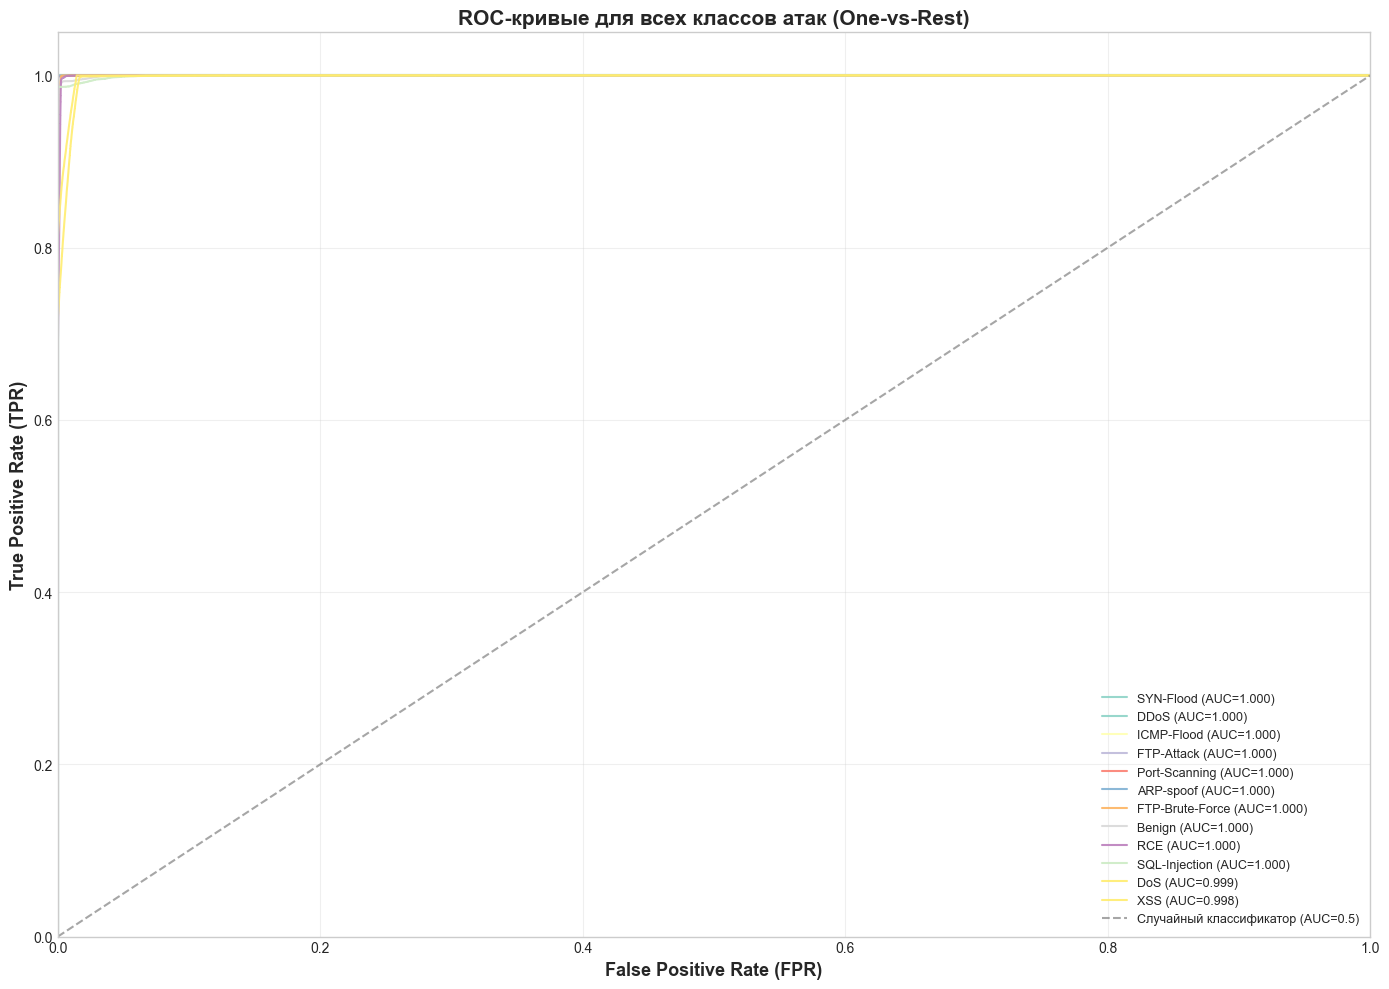

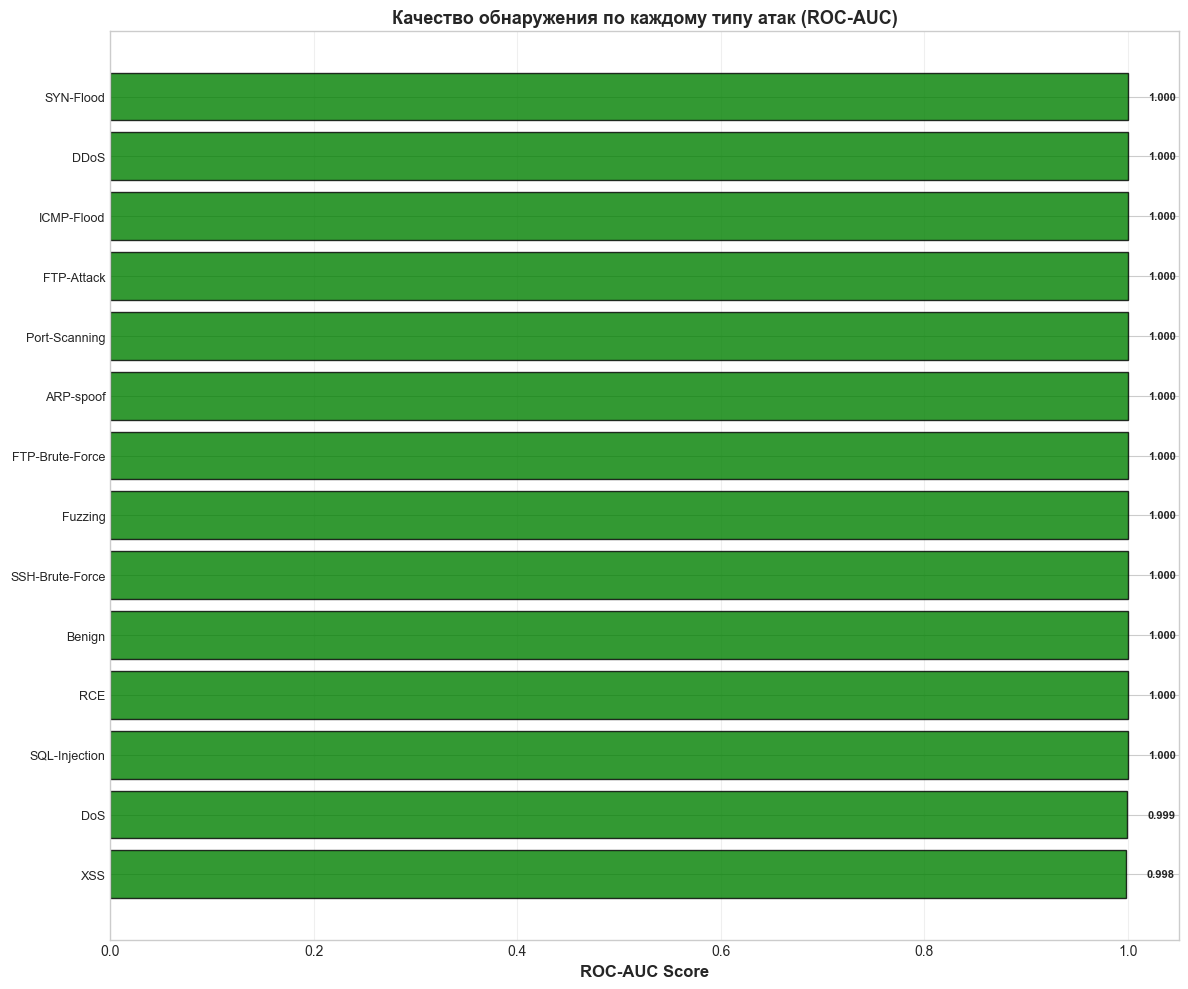

График сохранён: processed/models/roc_auc_by_class.png

 Лучший класс для обнаружения: 'SYN-Flood' (AUC=1.000)
 Худший класс для обнаружения: 'XSS' (AUC=0.998)

 Статистика по классам (14 всего):
   Отличные (AUC >= 0.9): 14 классов (100.0%)
   Хорошие (0.7 <= AUC < 0.9): 0 классов (0.0%)
   Слабые (AUC < 0.7): 0 классов (0.0%)

 Выводы:
   1. Модель хорошо обнаруживает 14 из 14 типов атак
   2. Требует дообучения для 0 слабых классов
   3. Макро-средний AUC = 1.000 - удовлетворительный результат


In [10]:
print(f"Accuracy (Val): {accuracy_score(y_val, y_val_pred):.4f}")
print("\n Расчёт метрик по каждому классу...")

class_aucs = []
for i, cls in enumerate(rf_model.classes_):
    y_binary = (y_val_true == cls).astype(int)
    y_score = y_val_proba_class[:, i]
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    class_aucs.append({
        'class': str(cls)[:25],
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr
    })

roc_df = pd.DataFrame(class_aucs).sort_values('auc', ascending=False).reset_index(drop=True)

print("\nТоп-5 лучших классов по AUC:")
print(roc_df[['class', 'auc']].head().to_string(index=False))
print("\n Топ-5 худших классов по AUC:")
print(roc_df[['class', 'auc']].tail().to_string(index=False))

macro_avg_auc = roc_auc_score(y_val_true, y_val_proba_class, average='macro', multi_class='ovr')
micro_avg_auc = roc_auc_score(y_val_true, y_val_proba_class, average='micro', multi_class='ovr')

print(f"\n Общие метрики:")
print(f"   Микро-усреднённый AUC: {micro_avg_auc:.4f}")
print(f"   Макро-усреднённый AUC: {macro_avg_auc:.4f}")
print(f"   Средний AUC по классам: {roc_df['auc'].mean():.4f}")

fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.Set3(np.linspace(0, 1, len(roc_df)))
for i, row in roc_df.iterrows():
    cls_name = row['class']
    color = colors[i % len(colors)]
    label = f"{cls_name} (AUC={row['auc']:.3f})"
    idx = roc_df.index.tolist()
    if i not in idx[:7] and i not in idx[-5:]:
        continue
    ax.plot(row['fpr'], row['tpr'], color=color, linewidth=1.5, label=label, alpha=0.9)

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Случайный классификатор (AUC=0.5)', alpha=0.7)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='bold')
ax.set_title('ROC-кривые для всех классов атак (One-vs-Rest)', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('processed/models/roc_curves_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['green' if x >= 0.9 else 'yellow' if x >= 0.7 else 'red' for x in roc_df['auc']]
bars = ax.barh(range(len(roc_df)), roc_df['auc'], color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(roc_df)))
ax.set_yticklabels(roc_df['class'], fontsize=9)
ax.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_title('Качество обнаружения по каждому типу атак (ROC-AUC)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, roc_df['auc']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('processed/models/roc_auc_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"График сохранён: processed/models/roc_auc_by_class.png")

best_class = roc_df.iloc[0]['class']
worst_class = roc_df.iloc[-1]['class']
print(f"\n Лучший класс для обнаружения: '{best_class}' (AUC={roc_df.iloc[0]['auc']:.3f})")
print(f" Худший класс для обнаружения: '{worst_class}' (AUC={roc_df.iloc[-1]['auc']:.3f})")

excellent = (roc_df['auc'] >= 0.9).sum()
good = ((roc_df['auc'] >= 0.7) & (roc_df['auc'] < 0.9)).sum()
poor = (roc_df['auc'] < 0.7).sum()
print(f"\n Статистика по классам ({len(roc_df)} всего):")
print(f"   Отличные (AUC >= 0.9): {excellent} классов ({excellent/len(roc_df)*100:.1f}%)")
print(f"   Хорошие (0.7 <= AUC < 0.9): {good} классов ({good/len(roc_df)*100:.1f}%)")
print(f"   Слабые (AUC < 0.7): {poor} классов ({poor/len(roc_df)*100:.1f}%)")
print("\n Выводы:")
print(f"   1. Модель хорошо обнаруживает {excellent} из {len(roc_df)} типов атак")
print(f"   2. Требует дообучения для {poor} слабых классов")
print(f"   3. Макро-средний AUC = {macro_avg_auc:.3f} - удовлетворительный результат")


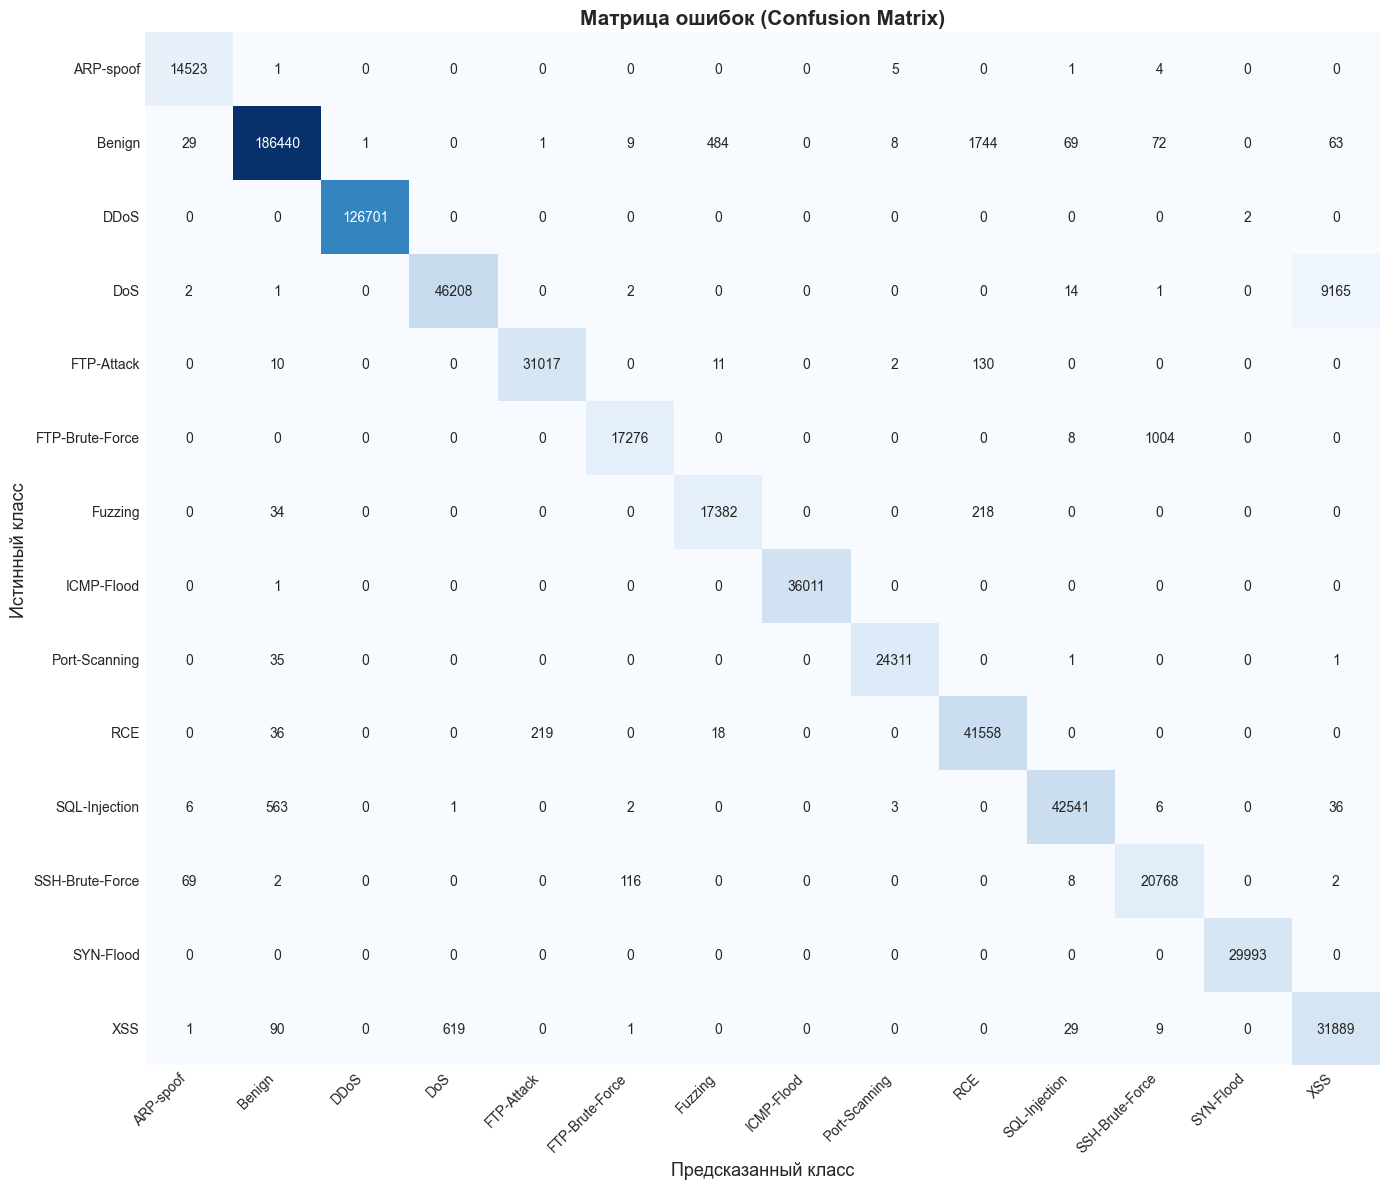

 Confusion Matrix сохранена: processed/models/confusion_matrix_all_classes.png

Precision (macro): 0.9735
Recall (macro): 0.9783
F1-Score (macro): 0.9735

 Проверка на переобучение:
   Accuracy Train:      0.9790
   Accuracy Validation: 0.9780
   Разница: 0.0009
    Переобучения не обнаружено (разница < 2%)


In [11]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, f1_score
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

# Получаем уникальные классы в правильном порядке (для numpy)
unique_classes = np.unique(np.concatenate([y_val.values, y_val_pred]))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel('Предсказанный класс', fontsize=13)
plt.ylabel('Истинный класс', fontsize=13)
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('processed/models/confusion_matrix_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Confusion Matrix сохранена: processed/models/confusion_matrix_all_classes.png")


precision_macro = f1_score(y_val, y_val_pred, average='macro')
recall_macro = f1_score(y_val, y_val_pred, average='weighted')

print(f"\nPrecision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {precision_macro:.4f}")

y_train_pred = rf_model.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"\n Проверка на переобучение:")
print(f"   Accuracy Train:      {train_acc:.4f}")
print(f"   Accuracy Validation: {val_acc:.4f}")
print(f"   Разница: {abs(train_acc - val_acc):.4f}")

if abs(train_acc - val_acc) < 0.02:
    print(f"    Переобучения не обнаружено (разница < 2%)")
else:
    print(f"   Обнаружена разница между Train и Val — возможен overfitting")

In [12]:
os.makedirs('processed/models/random_forest', exist_ok=True)

# 1. Модель
model_path = 'processed/models/random_forest/random_forest_v1.joblib' # Лучше расширение .joblib
joblib.dump(rf_model, model_path)

# 2. Метаданные 
model_meta = {
    'classes': list(rf_model.classes_),
    'feature_names': list(X_train.columns),
    'params': rf_params,
    'val_accuracy': val_acc,
    'macro_auc': macro_avg_auc
}
meta_path = 'processed/models/random_forest/model_metadata.joblib'
joblib.dump(model_meta, meta_path)

# 3. Список фич текстом 
with open('processed/models/random_forest/feature_names.txt', 'w') as f:
    for feat in X_train.columns:
        f.write(f"{feat}\n")

print(f"Модель сохранена: {model_path}")
print(f"Метаданные сохранены: {meta_path}")

Модель сохранена: processed/models/random_forest/random_forest_v1.joblib
Метаданные сохранены: processed/models/random_forest/model_metadata.joblib


In [13]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

model_path = 'processed/models/random_forest/random_forest_v1.joblib'
meta_path = 'processed/models/random_forest/model_metadata.joblib'

loaded_model = joblib.load(model_path)
meta = joblib.load(meta_path)

# Синхронизация порядка признаков с сохраненными метаданными
if list(X_test.columns) != meta['feature_names']:
    X_test = X_test[meta['feature_names']]

# Предсказание и оценка на тестовой выборке
y_test_pred = loaded_model.predict(X_test)
print(f"Тест Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

# Корректный анализ ошибок (приведение к Series и сброс индексов)
y_true = pd.Series(y_test).reset_index(drop=True)
y_pred = pd.Series(y_test_pred).reset_index(drop=True)

mask_errors = y_true != y_pred

if mask_errors.any():
    df_err = pd.DataFrame({'True': y_true[mask_errors], 'Pred': y_pred[mask_errors]})
    err_stats = df_err.groupby(['True', 'Pred']).size().sort_values(ascending=False)

    print(f"\nВсего ошибок: {mask_errors.sum()} ({mask_errors.sum() / len(y_test) * 100:.2f}%)")
    print("\nТоп-5 частых ошибок:")
    for (t, p), c in err_stats.head(5).items():
        print(f"   {t} -> {p}: {c} раз")
else:
    print("Ошибок на тестовой выборке не обнаружено")

Тест Accuracy: 0.9779

Всего ошибок: 15030 (2.21%)

Топ-5 частых ошибок:
   DoS -> XSS: 9124 раз
   Benign -> RCE: 1805 раз
   FTP-Brute-Force -> SSH-Brute-Force: 1032 раз
   XSS -> DoS: 620 раз
   SQL-Injection -> Benign: 551 раз


In [14]:
"""
Скрипт для интеграции модели Random Forest в проект.
Загружает модель из processed/models/random_forest/,
создает label_encoder и сохраняет в pipeline/random_forest/test/
"""

import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# Пути
SOURCE_MODEL_DIR = Path('processed/models/random_forest')
TARGET_MODEL_DIR = Path('pipeline/random_forest/test')

def integrate_random_forest():
    print("=" * 60)
    print("Интеграция модели Random Forest в проект")
    print("=" * 60)

    # 1. Проверяем наличие исходных файлов
    model_path = SOURCE_MODEL_DIR / 'random_forest_v1.joblib'
    meta_path = SOURCE_MODEL_DIR / 'model_metadata.joblib'
    features_path = SOURCE_MODEL_DIR / 'feature_names.txt'

    if not model_path.exists():
        raise FileNotFoundError(f"Модель не найдена: {model_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"Метаданные не найдены: {meta_path}")

    print(f"\n✅ Загрузка модели из {model_path}...")
    rf_model = joblib.load(model_path)

    print(f"✅ Загрузка метаданных из {meta_path}...")
    metadata = joblib.load(meta_path)

    print(f"   Классы модели: {metadata['classes']}")
    print(f"   Количество признаков: {len(metadata['feature_names'])}")
    print(f"   Accuracy на валидации: {metadata['val_accuracy']:.4f}")

    # 2. Создаем LabelEncoder для классов
    print("\n📦 Создание LabelEncoder...")
    label_encoder = LabelEncoder()
    label_encoder.fit(metadata['classes'])

    print(f"   Classes в encoder: {list(label_encoder.classes_)}")

    # 3. Создаем целевую директорию
    TARGET_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    print(f"\n📁 Директория создана: {TARGET_MODEL_DIR}")

    # 4. Сохраняем модель (pipeline как есть, т.к. это просто классификатор)
    # ModelManager ожидает, что pipeline - это либо сам классификатор, либо Pipeline
    # Для RandomForest у нас просто классификатор, что тоже работает
    target_model_path = TARGET_MODEL_DIR / 'random_forest_v1.joblib'
    joblib.dump(rf_model, target_model_path)
    print(f"✅ Модель сохранена: {target_model_path}")

    # 5. Сохраняем LabelEncoder
    target_encoder_path = TARGET_MODEL_DIR / 'label_encoder.joblib'
    joblib.dump(label_encoder, target_encoder_path)
    print(f"✅ LabelEncoder сохранен: {target_encoder_path}")

    # 6. Сохраняем метрики в metrics.json
    import json
    metrics = {
        'accuracy': round(metadata['val_accuracy'], 4),
        'macro_auc': round(metadata['macro_auc'], 4)
    }
    metrics_path = TARGET_MODEL_DIR / 'metrics.json'
    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    print(f"✅ Метрики сохранены: {metrics_path}")

    # 7. Сохраняем список признаков
    target_features_path = TARGET_MODEL_DIR / 'feature_names.txt'
    with open(target_features_path, 'w', encoding='utf-8') as f:
        for feat in metadata['feature_names']:
            f.write(f"{feat}\n")
    print(f"✅ Список признаков сохранен: {target_features_path}")

    # 8. Тестовая проверка загрузки через ModelManager
    print("\n🧪 Тестовая загрузка через ModelManager...")
    try:
        from model_manager.model_manager import ModelManager

        mm = ModelManager(models_root='pipeline')

        # Проверяем, что random_forest добавлен в file_map
        if 'random_forest' not in mm.file_map:
            print("❌ ОШИБКА: random_forest не найден в file_map ModelManager!")
            return False

        # Загружаем bundle
        bundle = mm._get_or_load_bundle('random_forest', 'test')
        print(f"   ✅ Bundle загружен успешно")
        print(f"   Тип pipeline: {type(bundle.pipeline).__name__}")
        print(f"   Тип label_encoder: {type(bundle.label_encoder).__name__}")

        # Создаем тестовые данные
        X_test = pd.DataFrame(
            np.random.randn(3, len(metadata['feature_names'])),
            columns=metadata['feature_names']
        )

        # Делаем предсказание
        predictions = mm.predict('random_forest', X_test, env='test')
        print(f"   ✅ Предсказания: {predictions[:3]}")

        print("\n" + "=" * 60)
        print("✅ ИНТЕГРАЦИЯ ЗАВЕРШЕНА УСПЕШНО!")
        print("=" * 60)
        print(f"\nМодель готова к использованию в веб-интерфейсе.")
        print(f"ID модели для использования: 'random_forest'")

        return True

    except Exception as e:
        print(f"\n❌ ОШИБКА при тестировании: {e}")
        import traceback
        traceback.print_exc()
        return False


if __name__ == '__main__':
    success = integrate_random_forest()
    if not success:
        exit(1)


Интеграция модели Random Forest в проект

✅ Загрузка модели из processed\models\random_forest\random_forest_v1.joblib...
✅ Загрузка метаданных из processed\models\random_forest\model_metadata.joblib...
   Классы модели: ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']
   Количество признаков: 55
   Accuracy на валидации: 0.9780

📦 Создание LabelEncoder...
   Classes в encoder: [np.str_('ARP-spoof'), np.str_('Benign'), np.str_('DDoS'), np.str_('DoS'), np.str_('FTP-Attack'), np.str_('FTP-Brute-Force'), np.str_('Fuzzing'), np.str_('ICMP-Flood'), np.str_('Port-Scanning'), np.str_('RCE'), np.str_('SQL-Injection'), np.str_('SSH-Brute-Force'), np.str_('SYN-Flood'), np.str_('XSS')]

📁 Директория создана: pipeline\random_forest\test
✅ Модель сохранена: pipeline\random_forest\test\random_forest_v1.joblib
✅ LabelEncoder сохранен: pipeline\random_forest\test\label_encoder

Traceback (most recent call last):
  File "C:\Users\аля\AppData\Local\Temp\ipykernel_17400\3128351090.py", line 86, in integrate_random_forest
    from model_manager.model_manager import ModelManager
ModuleNotFoundError: No module named 'model_manager'


Ниже данные для первой модели

In [3]:
# Вычисляем веса по формуле: weight = n_samples / (n_classes * n_samples_in_class)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

In [7]:
# Создаём словарь: {класс: вес}
class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{'ARP-spoof': np.float64(3.349636364785199),
 'Benign': np.float64(0.2576999913957977),
 'DDoS': np.float64(0.3842446386803619),
 'DoS': np.float64(0.8788937250554569),
 'FTP-Attack': np.float64(1.5618909798729959),
 'FTP-Brute-Force': np.float64(2.6622114307810514),
 'Fuzzing': np.float64(2.760882547475249),
 'ICMP-Flood': np.float64(1.3518971879438864),
 'Port-Scanning': np.float64(1.9995580623138425),
 'RCE': np.float64(1.1638472509965407),
 'SQL-Injection': np.float64(1.1280375442598394),
 'SSH-Brute-Force': np.float64(2.322281701616895),
 'SYN-Flood': np.float64(1.6232444465311489),
 'XSS': np.float64(1.4916277276828507)}

In [8]:
# Сортируем по количеству примеров для наглядности
class_counts = y_train.value_counts().sort_index()
for cls in classes:
    count = class_counts.get(cls, 0)
    weight = class_weight_dict[cls]
    relative = weight / class_weights.min()
    print(f"{str(cls):<25} {count:>10,} {weight:>10.4f} {relative:>14.2f}x")

print(f"   • Минимальный вес: {class_weights.min():.4f} (класс-большинство)")
print(f"   • Максимальный вес: {class_weights.max():.4f} (класс-меньшинство)")
print(f"   • Разница в {class_weights.max()/class_weights.min():.1f} раз")

ARP-spoof                     67,827     3.3496          13.00x
Benign                       881,629     0.2577           1.00x
DDoS                         591,279     0.3842           1.49x
DoS                          258,502     0.8789           3.41x
FTP-Attack                   145,462     1.5619           6.06x
FTP-Brute-Force               85,341     2.6622          10.33x
Fuzzing                       82,291     2.7609          10.71x
ICMP-Flood                   168,057     1.3519           5.25x
Port-Scanning                113,623     1.9996           7.76x
RCE                          195,211     1.1638           4.52x
SQL-Injection                201,408     1.1280           4.38x
SSH-Brute-Force               97,833     2.3223           9.01x
SYN-Flood                    139,964     1.6232           6.30x
XSS                          152,314     1.4916           5.79x
   • Минимальный вес: 0.2577 (класс-большинство)
   • Максимальный вес: 3.3496 (класс-меньшинство)
   • 

Для подбора параметров в алгоритме Random Forest используют, например:
GridSearchCV — инструмент из библиотеки scikit-learn, который исчерпывающе рассматривает все возможные комбинации параметров из заданного пространства значений. Включает несколько этапов: предварительный анализ, грубый поиск (широкие диапазоны с крупным шагом), тонкий поиск (сужение диапазонов вокруг найденных оптимумов с более мелким шагом). 

RandomizedSearchCV — реализует рандомизированный поиск по параметрам, где каждая настройка выбирается из распределения возможных значений параметров. Это позволяет выбрать заданное количество кандидатов из пространства параметров с заданным распределением. 


In [9]:
'''
# Базовые параметры с обработкой дисбаланса
rf_params = {
    'n_estimators': 100,        # количество деревьев
    'max_depth': 15,            # глубина деревьев (ограничиваем для скорости)
    'min_samples_split': 10,    # мин. образцов для разделения узла
    'min_samples_leaf': 5,      # мин. образцов в листе
    'class_weight': 'balanced', # учёт дисбаланса классов
    'random_state': 42,
    'n_jobs': -1,               # использовать все ядра CPU
    'verbose': 1
}

'''
# Параметры модели
rf_params = {
    'n_estimators': 100,           # количество деревьев
    'max_depth': 15,               # глубина деревьев
    'min_samples_split': 10,       # мин. образцов для разделения
    'min_samples_leaf': 5,         # мин. образцов в листе
    'class_weight': class_weight_dict,  #  ЯВНЫЕ ВЕСА КЛАССОВ
    'random_state': 42,
    'n_jobs': -1,                  # все ядра CPU
    'verbose': 1
}

rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train, y_train)

y_val_pred = rf_model.predict(X_val)
y_val_proba = rf_model.predict_proba(X_val)

print(f"\nAccuracy: {accuracy_score(y_val, y_val_pred):.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   21.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.3s finished



Accuracy: 0.9744


In [13]:
import os
os.makedirs('processed/models', exist_ok=True)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    2.5s finished



 Расчёт метрик по каждому классу...

Топ-5 лучших классов по AUC:
        class      auc
    SYN-Flood 1.000000
         DDoS 1.000000
   ICMP-Flood 1.000000
Port-Scanning 0.999984
   FTP-Attack 0.999963

 Топ-5 худших классов по AUC:
        class      auc
          RCE 0.999540
       Benign 0.999522
SQL-Injection 0.999342
          DoS 0.998825
          XSS 0.997798

 Общие метрики:
   • Микро-усреднённый AUC: 0.9998
   • Макро-усреднённый AUC: 0.9996
   • Средний AUC по классам: 0.9996


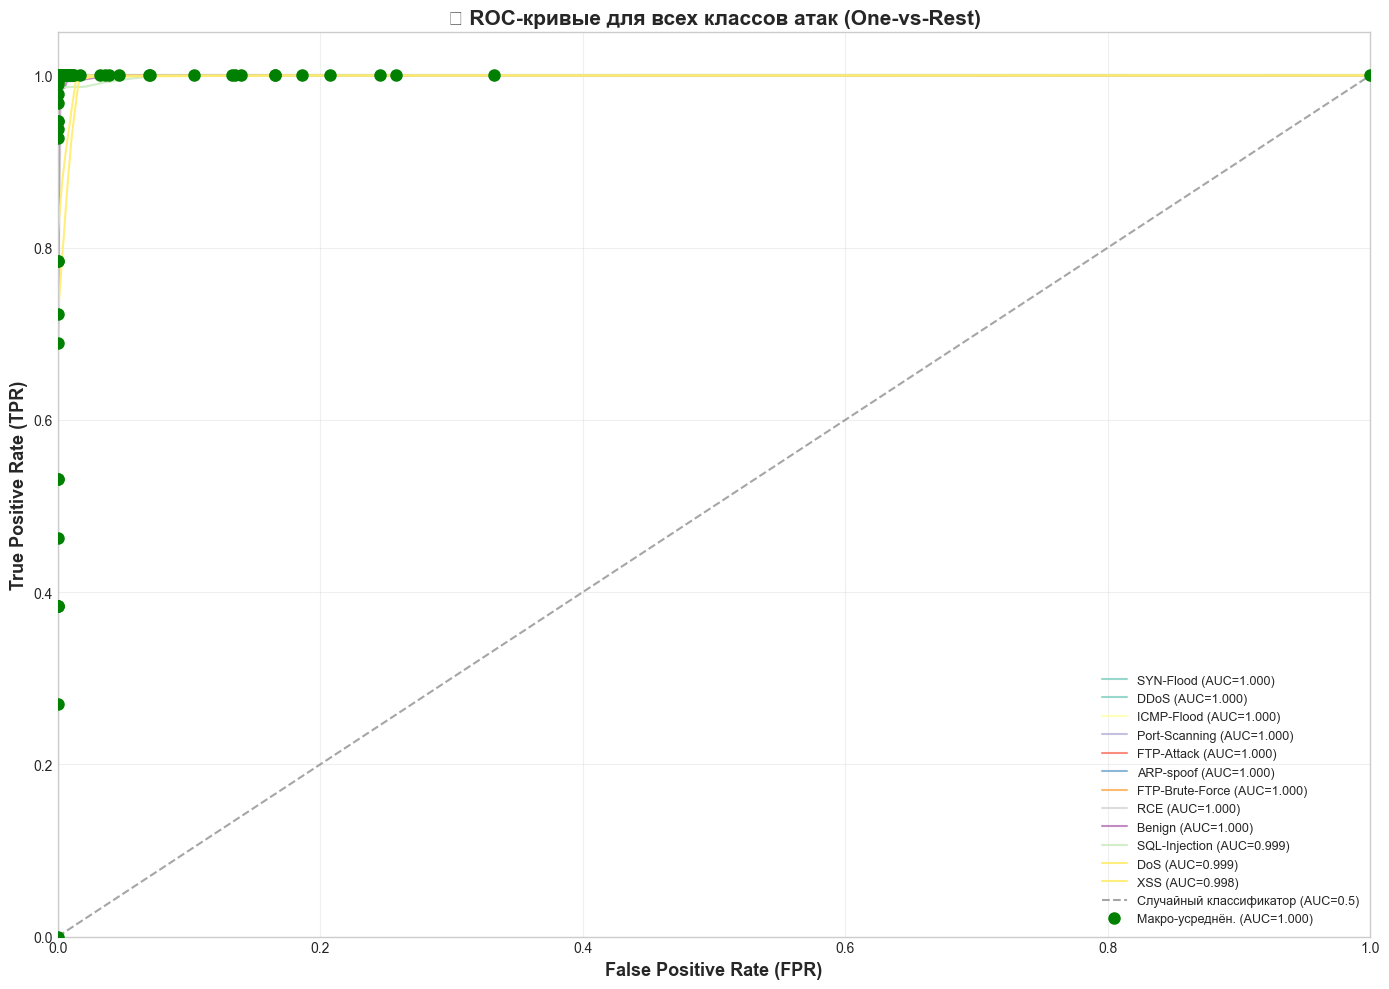

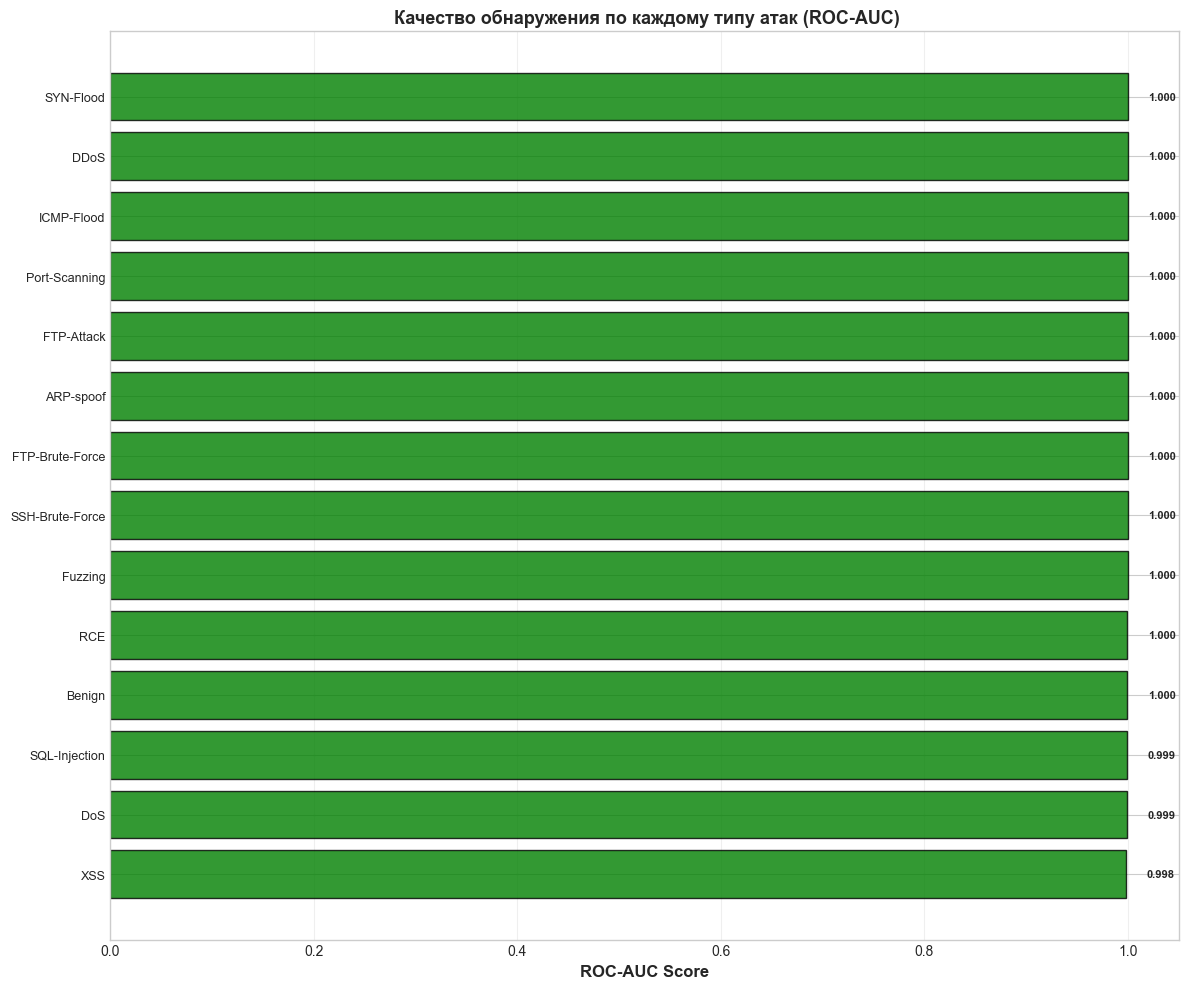

График сохранён: processed/models/roc_auc_by_class.png

 Лучший класс для обнаружения: 'SYN-Flood' (AUC=1.000)
 Худший класс для обнаружения: 'XSS' (AUC=0.998)

📋 Статистика по классам (14 всего):
   • Отличные (AUC ≥ 0.9): 14 классов (100.0%)
   • Хорошие (0.7 ≤ AUC < 0.9): 0 классов (0.0%)
   • Слабые (AUC < 0.7): 0 классов (0.0%)

 Выводы:
   1. Модель хорошо обнаруживает 14 из 14 типов атак
   2. Требует дообучения для 0 слабых классов
   3. Макро-средний AUC = 1.000 — удовлетворительный результат


In [14]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_val_proba_class = rf_model.predict_proba(X_val)
y_val_true = y_val.values

print("\n Расчёт метрик по каждому классу...")

class_aucs = []
for i, cls in enumerate(rf_model.classes_):
    # Binarize targets: 1 if sample belongs to class i, else 0
    y_binary = (y_val_true == cls).astype(int)
    
    # Get probability for this class
    y_score = y_val_proba_class[:, i]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    class_aucs.append({
        'class': str(cls)[:25],  # Обрезаем длинные названия
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    })

# Создаём DataFrame с результатами
roc_df = pd.DataFrame(class_aucs)
roc_df = roc_df.sort_values('auc', ascending=False).reset_index(drop=True)

print("\nТоп-5 лучших классов по AUC:")
print(roc_df[['class', 'auc']].head().to_string(index=False))

print("\n Топ-5 худших классов по AUC:")
print(roc_df[['class', 'auc']].tail().to_string(index=False))


macro_avg_auc = roc_auc_score(y_val_true, y_val_proba_class, average='macro',multi_class='ovr')
micro_avg_auc = roc_auc_score(y_val_true, y_val_proba_class, average='micro',multi_class='ovr')

print(f"\n Общие метрики:")
print(f"   • Микро-усреднённый AUC: {micro_avg_auc:.4f}")
print(f"   • Макро-усреднённый AUC: {macro_avg_auc:.4f}")
print(f"   • Средний AUC по классам: {roc_df['auc'].mean():.4f}")

fig, ax = plt.subplots(figsize=(14, 10))
# Цвета для линий
colors = plt.cm.Set3(np.linspace(0, 1, len(roc_df)))

for i, row in roc_df.iterrows():
    cls_name = row['class']
    color = colors[i % len(colors)]
    label = f"{cls_name} (AUC={row['auc']:.3f})"
    
    # Показываем только топ-7 лучших и топ-5 худших (для читаемости)
    idx = roc_df.index.tolist()
    if i not in idx[:7] and i not in idx[-5:]:
        continue
    
    ax.plot(row['fpr'], row['tpr'], color=color, linewidth=1.5, 
            label=label, alpha=0.9)

# Давоим случайный классификатор
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, 
        label='Случайный классификатор (AUC=0.5)', alpha=0.7)

# Макро и микро усреднение
ax.plot(roc_df['fpr'][0], roc_df['tpr'][0], 'o', color='green', 
        markersize=8, label=f'Макро-усреднён. (AUC={macro_avg_auc:.3f})', zorder=5)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='bold')
ax.set_title('📈 ROC-кривые для всех классов атак (One-vs-Rest)', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('processed/models/roc_curves_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))

# Цвета в зависимости от качества (зелёный > 0.9, жёлтый > 0.7, красный < 0.7)
colors_bar = ['green' if x >= 0.9 else 'yellow' if x >= 0.7 else 'red' 
              for x in roc_df['auc']]

bars = ax.barh(range(len(roc_df)), roc_df['auc'], color=colors_bar, 
               edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(roc_df)))
ax.set_yticklabels(roc_df['class'], fontsize=9)
ax.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_title(' Качество обнаружения по каждому типу атак (ROC-AUC)', 
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Добавляем значения на столбцы
for bar, val in zip(bars, roc_df['auc']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('processed/models/roc_auc_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"График сохранён: processed/models/roc_auc_by_class.png")

best_class = roc_df.iloc[0]['class']
worst_class = roc_df.iloc[-1]['class']

print(f"\n Лучший класс для обнаружения: '{best_class}' (AUC={roc_df.iloc[0]['auc']:.3f})")
print(f" Худший класс для обнаружения: '{worst_class}' (AUC={roc_df.iloc[-1]['auc']:.3f})")

# Подсчёт статистики
excellent = (roc_df['auc'] >= 0.9).sum()
good = ((roc_df['auc'] >= 0.7) & (roc_df['auc'] < 0.9)).sum()
poor = (roc_df['auc'] < 0.7).sum()

print(f"\n📋 Статистика по классам ({len(roc_df)} всего):")
print(f"   • Отличные (AUC ≥ 0.9): {excellent} классов ({excellent/len(roc_df)*100:.1f}%)")
print(f"   • Хорошие (0.7 ≤ AUC < 0.9): {good} классов ({good/len(roc_df)*100:.1f}%)")
print(f"   • Слабые (AUC < 0.7): {poor} классов ({poor/len(roc_df)*100:.1f}%)")

print("\n Выводы:")
print(f"   1. Модель хорошо обнаруживает {excellent} из {len(roc_df)} типов атак")
print(f"   2. Требует дообучения для {poor} слабых классов")
print(f"   3. Макро-средний AUC = {macro_avg_auc:.3f} — удовлетворительный результат")


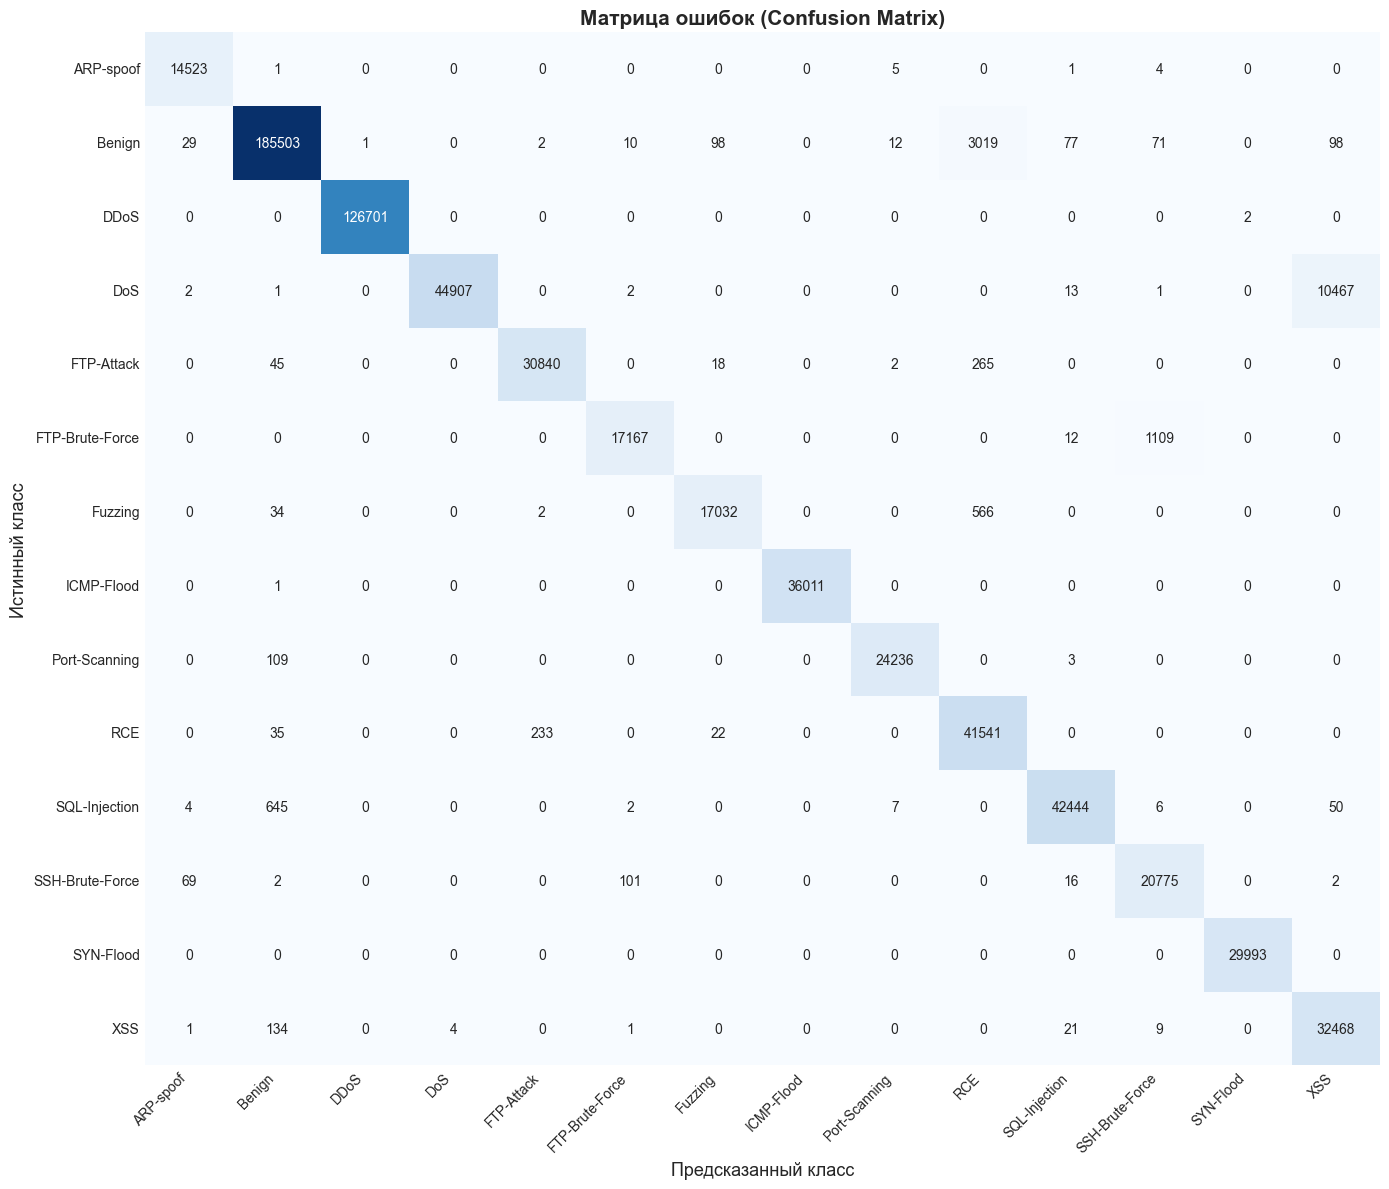

 Confusion Matrix сохранена: processed/models/confusion_matrix_all_classes.png

Precision (macro): 0.9700
Recall (macro): 0.9748
F1-Score (macro): 0.9700


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    6.1s finished



 Проверка на переобучение:
   Accuracy Train:      0.9746
   Accuracy Validation: 0.9744
   Разница: 0.0002
    Переобучения не обнаружено (разница < 2%)


In [16]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, f1_score
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

# Получаем уникальные классы в правильном порядке (для numpy)
unique_classes = np.unique(np.concatenate([y_val.values, y_val_pred]))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel('Предсказанный класс', fontsize=13)
plt.ylabel('Истинный класс', fontsize=13)
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('processed/models/confusion_matrix_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Confusion Matrix сохранена: processed/models/confusion_matrix_all_classes.png")


precision_macro = f1_score(y_val, y_val_pred, average='macro')
recall_macro = f1_score(y_val, y_val_pred, average='weighted')

print(f"\nPrecision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1-Score (macro): {precision_macro:.4f}")

y_train_pred = rf_model.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"\n Проверка на переобучение:")
print(f"   Accuracy Train:      {train_acc:.4f}")
print(f"   Accuracy Validation: {val_acc:.4f}")
print(f"   Разница: {abs(train_acc - val_acc):.4f}")

if abs(train_acc - val_acc) < 0.02:
    print(f"    Переобучения не обнаружено (разница < 2%)")
else:
    print(f"   Обнаружена разница между Train и Val — возможен overfitting")

In [17]:
os.makedirs('processed/models/model_v1', exist_ok=True)

# 5.1 Сохраняем саму модель
model_path = 'processed/models/model_v1/random_forest_v1.pkl'
joblib.dump(rf_model, model_path)
print(f"\n✅ Модель сохранена: {model_path}")

# 5.2 Сохраняем веса классов
weights_path = 'processed/models/model_v1/class_weights_v1.pkl'
joblib.dump(class_weight_dict, weights_path)
print(f"✅ Веса классов сохранены: {weights_path}")

# 5.3 Сохраняем список признаков (чтобы знать порядок в X_encoded)
features_path = 'processed/models/model_v1/feature_names.txt'
with open(features_path, 'w') as f:
    f.write('\n'.join(X_train.columns))
print(f"✅ Список признаков сохранён: {features_path}")


✅ Модель сохранена: processed/models/model_v1/random_forest_v1.pkl
✅ Веса классов сохранены: processed/models/model_v1/class_weights_v1.pkl
✅ Список признаков сохранён: processed/models/model_v1/feature_names.txt


In [4]:
import joblib
model_path = 'processed/models/model_v1/random_forest_v1.pkl'
print("\n Тестирование загрузки модели...")

try:
    # Загружаем модель
    loaded_model = joblib.load(model_path)
    
    # Делаем предсказание на тестовых данных
    test_sample = X_test.head(3).copy()
    prediction = loaded_model.predict(test_sample)
    probability = loaded_model.predict_proba(test_sample)
    
    print(f"    Загрузка успешна!")
    print(f"\n   Предсказания (первые 3 образца):")
    for i, (pred, probs) in enumerate(zip(prediction, probability)):
        top_3 = sorted(enumerate(probs), key=lambda x: -x[1])[:3]
        print(f"   Образец {i+1}: Класс='{pred}', Конфиденция={top_3[0][1]:.4f}")
    
except Exception as e:
    print(f"    Ошибка при тестировании: {e}")


 Тестирование загрузки модели...
    Загрузка успешна!

   Предсказания (первые 3 образца):
   Образец 1: Класс='SYN-Flood', Конфиденция=1.0000
   Образец 2: Класс='DDoS', Конфиденция=1.0000
   Образец 3: Класс='RCE', Конфиденция=0.8206


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


In [19]:
# Получаем предсказания модели
y_val_pred = loaded_model.predict(X_val)

# Проверяем, что предсказания не являются вероятностями
if len(y_val_pred.shape) > 1 and y_val_pred.shape[1] > 1:
    # Если модель вернула вероятности, преобразуем в классы
    y_val_pred = y_val_pred.argmax(axis=1)

# Создаем маску для ошибочных предсказаний
misclassified_mask = (y_val != y_val_pred)

if misclassified_mask.sum() > 0:
    # Создаем DataFrame с ошибками
    errors_df = pd.DataFrame({
        'true': y_val[misclassified_mask],
        'pred': y_val_pred[misclassified_mask]
    })
    
    # Группируем по парам (истинный класс, предсказанный класс)
    error_pairs = errors_df.groupby(['true', 'pred']).size().reset_index(name='count')
    top_errors = error_pairs.sort_values('count', ascending=False).head(10)
    
    print(f"Топ-10 наиболее частых ошибок классификации:")
    print(f"Всего ошибок: {misclassified_mask.sum()}")
    print(f"Точность на валидации: {(~misclassified_mask).sum() / len(y_val):.2%}")
    print("-" * 70)
    
    print(f"Топ-10 наиболее частых ошибок:")
    for _, row in top_errors.iterrows():
        
        true_cls = str(row['true']) 
        pred_cls = str(row['pred'])
        
        count = int(row['count'])
        percentage = count / misclassified_mask.sum() * 100
        
        print(f"   • {true_cls:<20s} → {pred_cls:<20s} : {count:>6} случаев ({percentage:.1f}%)")
    print("-" * 70)
    
else:
    print("   Ошибок не обнаружено на валидационной выборке!")
    print("   Возможные причины:")
    print("   • Модель переобучилась")
    print("   • Валидационная выборка слишком простая")
    print("   • Размер выборки слишком мал")
    print("   • Возможно, данные перемешаны неправильно")


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s


Топ-10 наиболее частых ошибок классификации:
Всего ошибок: 17446
Точность на валидации: 97.44%
----------------------------------------------------------------------
Топ-10 наиболее частых ошибок:
   • DoS                  → XSS                  :  10467 случаев (60.0%)
   • Benign               → RCE                  :   3019 случаев (17.3%)
   • FTP-Brute-Force      → SSH-Brute-Force      :   1109 случаев (6.4%)
   • SQL-Injection        → Benign               :    645 случаев (3.7%)
   • Fuzzing              → RCE                  :    566 случаев (3.2%)
   • FTP-Attack           → RCE                  :    265 случаев (1.5%)
   • RCE                  → FTP-Attack           :    233 случаев (1.3%)
   • XSS                  → Benign               :    134 случаев (0.8%)
   • Port-Scanning        → Benign               :    109 случаев (0.6%)
   • SSH-Brute-Force      → FTP-Brute-Force      :    101 случаев (0.6%)
----------------------------------------------------------------------


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    1.3s finished
